In [1]:
from utilsforecast.preprocessing import fill_gaps
from tinyshift.stats import remove_leading_zeros, is_obsolete
from tinyshift.plot import stationarity_analysis, pami, residual_analysis, seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from statsmodels.tsa.seasonal import MSTL
from statsforecast.models import SeasonalNaive, AutoETS
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias, cfe
from tinyshift.modelling import DMSTLWrapper, fourier_seasonality
from mlforecast.utils import PredictionIntervals
from tinyshift.series import (
    wape,
    pbias,
    score,
    forecast_instability,
    detect_seasonal_periods,
    extract_mstl_components,
    fva_rmae,
    mach,
    permutation_auto_mutual_information,
)

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df["unique_id"] = "1"
df.rename(columns={"Month": "ds", "Passengers": "y"}, inplace=True)
df = fill_gaps(df, freq="ME", end="per_serie", id_col="unique_id", time_col="ds")
df = df.groupby("unique_id")[df.columns].apply(remove_leading_zeros).reset_index(drop=True)
df = fourier_seasonality(df, "ds", seasonality=["monthly"])
days_obsoletes=180
obsolete_series = df.groupby("unique_id")[df.columns].apply(is_obsolete, days_obsoletes)
obsolote_ids = obsolete_series[obsolete_series].index.tolist()
assert len(obsolote_ids) == 0, f"Obsolete series found: {obsolote_ids}"

In [3]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

In [4]:
df.isnull().sum()

unique_id      0
ds             0
y              0
monthly_sin    0
monthly_cos    0
dtype: int64

Resultado agregado com FFT e PAMI automáticos do DMSTLWrapper:


,MAE,RMSE,actual_total,forecast_total,total_error_pct
DMSTL_auto_FFT_PAMI,749.976779,1183.047736,28932.0,27383.076296,-5.35367


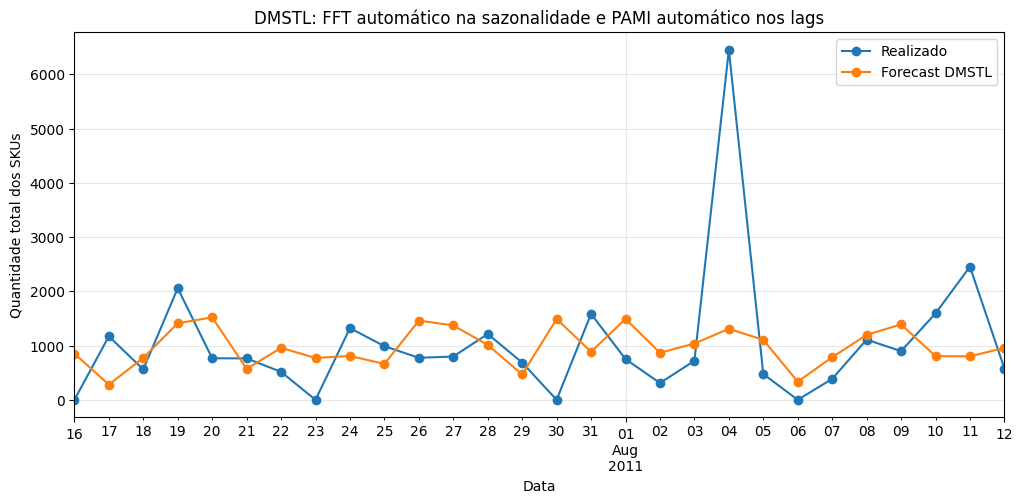

In [5]:
from pathlib import Path
from scipy.signal import find_peaks


def first_pami_local_minimum(values, max_tau=365, m=3, delay=1):
    values = np.asarray(values, dtype=float)
    max_valid_tau = len(values) - (m - 1) * delay - 1
    taus = np.arange(1, min(max_tau, max_valid_tau) + 1)
    pami_values = np.array([
        permutation_auto_mutual_information(
            values, tau=int(tau), m=m, delay=delay, normalize=True
        )
        for tau in taus
    ])
    minima, _ = find_peaks(-pami_values)
    position = minima[0] if len(minima) else int(np.argmin(pami_values))
    return int(taus[position]), float(pami_values[position])


# Online Retail II: mesmo painel diário e os mesmos 12 SKUs do demand_class.
dataset_dir = Path(kagglehub.dataset_download("mashlyn/online-retail-ii-uci"))
retail_files = list(dataset_dir.rglob("*.csv"))
raw_retail = pd.read_csv(retail_files[0], encoding="latin1")
price_col = "Price" if "Price" in raw_retail.columns else "UnitPrice"
retail = raw_retail[["StockCode", "InvoiceDate", "Quantity", price_col]].copy()
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
retail["StockCode"] = retail["StockCode"].astype(str)
retail = retail.loc[
    retail["InvoiceDate"].notna()
    & (retail["Quantity"] > 0)
    & (retail[price_col] > 0)
].copy()
retail["ds"] = retail["InvoiceDate"].dt.floor("D")

benchmark_skus = (
    retail.groupby("StockCode")["Quantity"]
    .sum()
    .nlargest(12)
    .index
    .tolist()
)
retail = retail[retail["StockCode"].isin(benchmark_skus)].copy()
dates = pd.date_range(retail["ds"].min(), retail["ds"].max(), freq="D")
benchmark_panel = pd.MultiIndex.from_product(
    [dates, benchmark_skus], names=["ds", "unique_id"]
).to_frame(index=False)
benchmark_values = (
    retail.groupby(["ds", "StockCode"])["Quantity"]
    .sum()
    .rename("y")
    .reset_index()
    .rename(columns={"StockCode": "unique_id"})
)
benchmark_panel = benchmark_panel.merge(
    benchmark_values, on=["ds", "unique_id"], how="left"
)
benchmark_panel["y"] = benchmark_panel["y"].fillna(0.0)

benchmark_cutoff = benchmark_panel["ds"].quantile(0.80)
benchmark_train = benchmark_panel[benchmark_panel["ds"] <= benchmark_cutoff].copy()
benchmark_test = benchmark_panel[benchmark_panel["ds"] > benchmark_cutoff].copy()
benchmark_horizon = 28

# Os periodos sazonais continuam vindo do FFT; PAMI entra como feature do residual.
detected_periods_by_sku = detect_seasonal_periods(
    benchmark_train,
    unique_id_col="unique_id",
    target_col="y",
    top_k=2,
)

def residual_model_callable(nlags, freq):
    return MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq=freq,
        lags=nlags,
    )

def callable_seasonal(period):
    return AutoETS(season_length=period, model="ZNA", alias=f"AutoETS-{period}")


def callable_trend():
    return AutoETS(model="ZAN", alias="Trend-AutoETS")


dmstl_pami = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
    nlags=[1, 7, 14, 28],
    freq="D",
    seasonal_detection_params={"fallback": [7], "top_k": 3},
)
dmstl_pami.fit(benchmark_train, target_col="y")
forecast_pami = dmstl_pami.predict(h=benchmark_horizon).rename(
    columns={"RandomForestRegressor": "forecast_pami"}
)
comparison_pami = benchmark_test.merge(
    forecast_pami[["unique_id", "ds", "forecast_pami"]],
    on=["unique_id", "ds"],
)
comparison_pami["forecast_pami"] = comparison_pami["forecast_pami"].clip(lower=0)
pami_aggregate = comparison_pami.groupby("ds")[["y", "forecast_pami"]].sum()
pami_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(pami_aggregate["y"], pami_aggregate["forecast_pami"])],
        "RMSE": [mean_squared_error(pami_aggregate["y"], pami_aggregate["forecast_pami"]) ** 0.5],
        "actual_total": [pami_aggregate["y"].sum()],
        "forecast_total": [pami_aggregate["forecast_pami"].sum()],
    },
    index=["DMSTL_auto_FFT_PAMI"],
)
pami_metrics["total_error_pct"] = 100 * (
    pami_metrics["forecast_total"] / pami_metrics["actual_total"] - 1
)

print("Resultado agregado com FFT e PAMI automáticos do DMSTLWrapper:")
display(pami_metrics)
ax = pami_aggregate.plot(figsize=(12, 5), marker="o")
ax.set_title("DMSTL: FFT automático na sazonalidade e PAMI automático nos lags")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Forecast DMSTL"])
ax.grid(alpha=0.3)
plt.show()

Resultado agregado com FFT e PAMI automáticos do DMSTLWrapper:


,MAE,RMSE,actual_total,forecast_total,total_error_pct
DMSTL_auto_FFT_PAMI,735.537382,1189.655752,28932.0,30120.569204,4.108147


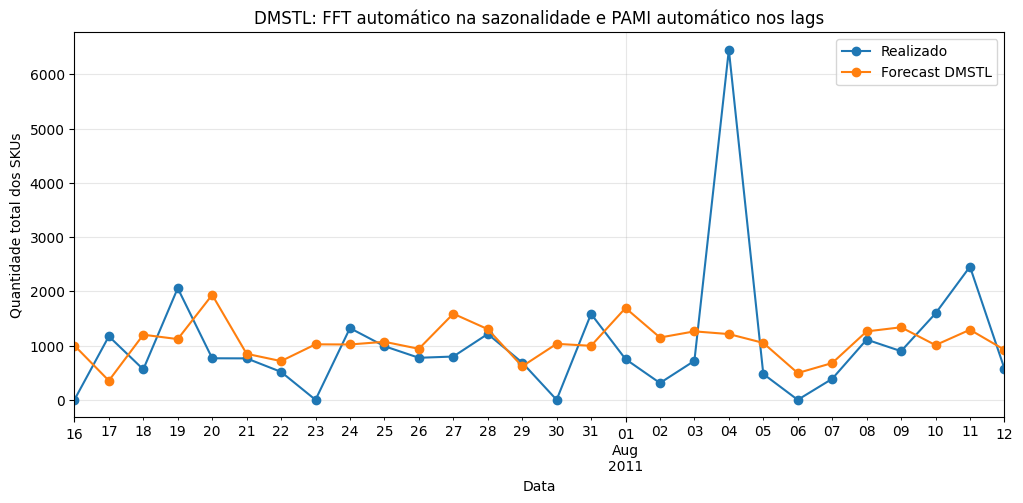

In [15]:
# O wrapper detecta os periodos via FFT e os lags do residual via PAMI.
def residual_model_callable(nlags, freq):
    return MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq=freq,
        lags=nlags,
    )


dmstl_pami_lag = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="D",
    seasonal_detection_params={"top_k": 2, "fallback": [7]},
    nlags="auto",
    pami_params={"max_tau": 30, "m": 3, "delay": 1, "return_mode": "point", "fallback": 1},
)
dmstl_pami_lag.fit(benchmark_train, target_col="y")
forecast_pami_lag = dmstl_pami_lag.predict(h=benchmark_horizon).rename(
    columns={"RandomForestRegressor": "forecast_pami_lag"}
)
comparison_pami_lag = benchmark_test.merge(
    forecast_pami_lag[["unique_id", "ds", "forecast_pami_lag"]],
    on=["unique_id", "ds"],
)
comparison_pami_lag["forecast_pami_lag"] = comparison_pami_lag["forecast_pami_lag"].clip(lower=0)
pami_lag_aggregate = comparison_pami_lag.groupby("ds")[["y", "forecast_pami_lag"]].sum()
pami_lag_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(pami_lag_aggregate["y"], pami_lag_aggregate["forecast_pami_lag"])],
        "RMSE": [mean_squared_error(pami_lag_aggregate["y"], pami_lag_aggregate["forecast_pami_lag"]) ** 0.5],
        "actual_total": [pami_lag_aggregate["y"].sum()],
        "forecast_total": [pami_lag_aggregate["forecast_pami_lag"].sum()],
    },
    index=["DMSTL_auto_FFT_PAMI"],
)
pami_lag_metrics["total_error_pct"] = 100 * (
    pami_lag_metrics["forecast_total"] / pami_lag_metrics["actual_total"] - 1
)

print("Resultado agregado com FFT e PAMI automáticos do DMSTLWrapper:")
display(pami_lag_metrics)
ax = pami_lag_aggregate.plot(figsize=(12, 5), marker="o")
ax.set_title("DMSTL: FFT automático na sazonalidade e PAMI automático nos lags")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Forecast DMSTL"])
ax.grid(alpha=0.3)
plt.show()

In [7]:
dmstl_pami_lag.fitted_models_

{'17003': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-3]),
   StatsForecast(models=[SeasonalNaive-4])],
  'residual': MLForecast(models=[RandomForestRegressor], freq=D, lag_features=['lag6'], date_features=[], num_threads=1)},
 '21212': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-2]),
   StatsForecast(models=[SeasonalNaive-7])],
  'residual': MLForecast(models=[RandomForestRegressor], freq=D, lag_features=['lag3'], date_features=[], num_threads=1)},
 '21977': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-5]),
   StatsForecast(models=[SeasonalNaive-7])],
  'residual': MLForecast(models=[RandomForestRegressor], freq=D, lag_features=['lag3'], date_features=[], num_threads=1)},
 '22197': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-2]),
   StatsForecast(models=[SeasonalNaive-7])],
  'residual': M

In [8]:
class DMSTLWrapperResidualCallable(DMSTLWrapper):
    """DMSTL que cria um modelo de residual separado para cada SKU."""

    def __init__(self, residual_model_callable, season_length, **kwargs):
        template_model = residual_model_callable(None)
        super().__init__(mf_resid=template_model, season_length=season_length, **kwargs)
        self.residual_model_callable = residual_model_callable

    def _fit_mlforecast(self, group, residual_part, prediction_intervals=None):
        mf_resid = self.residual_model_callable(group[self.id_col_].iloc[0])
        df_residual = group[[self.id_col_, self.time_col_] + self.exog_cols_].copy()
        df_residual[self.target_col_] = residual_part
        mf_resid.fit(
            df_residual,
            id_col=self.id_col_,
            time_col=self.time_col_,
            target_col=self.target_col_,
            prediction_intervals=prediction_intervals,
        )
        return mf_resid


# O FFT continua definindo a sazonalidade; o primeiro minimo local do PAMI define o lag do residual.
pami_lags_by_sku = {}
for uid, group in benchmark_train.groupby("unique_id"):
    pami_lags_by_sku[uid], _ = first_pami_local_minimum(group["y"].to_numpy())


def residual_model_callable(uid):
    lag = pami_lags_by_sku.get(uid, 1)
    return MLForecast(
        models=[RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)],
        freq="D",
        lags=[lag],
    )


dmstl_pami_lag = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    seasonal_detection_params={"top_k": 2, "fallback": [7]},
    trend_model_callable=callable_trend,
    seasonal_model_callable=callable_seasonal,
)
dmstl_pami_lag.fit(benchmark_train, target_col="y", freq="D")
forecast_pami_lag = dmstl_pami_lag.predict(h=benchmark_horizon).rename(
    columns={"RandomForestRegressor": "forecast_pami_lag"}
)
comparison_pami_lag = benchmark_test.merge(
    forecast_pami_lag[["unique_id", "ds", "forecast_pami_lag"]],
    on=["unique_id", "ds"],
)
comparison_pami_lag["forecast_pami_lag"] = comparison_pami_lag["forecast_pami_lag"].clip(lower=0)
pami_lag_aggregate = comparison_pami_lag.groupby("ds")[["y", "forecast_pami_lag"]].sum()
pami_lag_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(pami_lag_aggregate["y"], pami_lag_aggregate["forecast_pami_lag"])],
        "RMSE": [mean_squared_error(pami_lag_aggregate["y"], pami_lag_aggregate["forecast_pami_lag"]) ** 0.5],
        "actual_total": [pami_lag_aggregate["y"].sum()],
        "forecast_total": [pami_lag_aggregate["forecast_pami_lag"].sum()],
    },
    index=["DMSTL_FFT_PAMI_lag_residual_callable"],
)
pami_lag_metrics["total_error_pct"] = 100 * (
    pami_lag_metrics["forecast_total"] / pami_lag_metrics["actual_total"] - 1
)

print("Lags do residual definidos pelo primeiro minimo local do PAMI:")
display(pd.Series(pami_lags_by_sku, name="residual_lag"))
print("Resultado agregado com residual_model_callable:")
display(pami_lag_metrics)
ax = pami_lag_aggregate.plot(figsize=(12, 5), marker="o")
ax.set_title("DMSTL: FFT na sazonalidade e PAMI nos lags do residual")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade total dos SKUs")
ax.legend(["Realizado", "Forecast DMSTL"])
ax.grid(alpha=0.3)
plt.show()
pami_lag_aggregate

TypeError: DMSTLWrapper.fit() got an unexpected keyword argument 'freq'

In [ ]:
pami_lags_by_sku

{'17003': 3,
 '21212': 5,
 '21977': 3,
 '22197': 3,
 '22492': 3,
 '23166': 3,
 '23843': 1,
 '84077': 3,
 '84879': 3,
 '84991': 5,
 '85099B': 3,
 '85123A': 3}